In [ ]:
#part of the code refer to the https://github.com/AI4Finance-Foundation/FinRL.git
## install finrl library
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /tmp/pip-req-build-qe7u01q8
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /tmp/pip-req-build-qe7u01q8
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit d25d902a6de54931a329adc38a2663e8f576adc4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /tmp/pip-install-3oouum4x/elegantrl_e4c401bbc4c7415c94fb3bf5739fce73
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /tmp/pip-install-3oouum4x/elegantrl_e4c401bbc4c7415c94fb3bf5739fce73
  Resolved https://github.com/AI4Finance-Foundation/ElegantRL.git to commit 5e828af1503098f4da046c0f12432dbd4ef8bd97
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.7/10

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3

from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.config import INDICATORS, TRAINED_MODEL_DIR
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader

%matplotlib inline

In [2]:
!pip install pandas_market_calendars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.4/198.4 kB 22.8 MB/s eta 0:00:00


In [5]:
train = pd.read_csv('train_data.csv')
trade = pd.read_csv('trade_data.csv')

# If you are not using the data generated from part 1 of this tutorial, make sure
# it has the columns and index in the form that could be make into the environment.
# Then you can comment and skip the following lines.
train = train.set_index(train.columns[0])
train.index.names = ['']
trade = trade.set_index(trade.columns[0])
trade.index.names = ['']

In [6]:
if_using_a2c = True
if_using_ddpg = True
if_using_ppo = True
if_using_td3 = True
if_using_sac = True

In [7]:
trained_a2c = A2C.load("agent_a2c") if if_using_a2c else None
trained_ddpg = DDPG.load("agent_ddpg") if if_using_ddpg else None
trained_ppo = PPO.load("agent_ppo") if if_using_ppo else None
trained_td3 = TD3.load("agent_td3") if if_using_td3 else None
trained_sac = SAC.load("agent_sac") if if_using_sac else None

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force 

In [ ]:
#trading (testing)
stock_dimension = len(trade.tic.unique())
state_space = 1 + 2 * stock_dimension + len(INDICATORS) * stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 29, State Space: 291


In [10]:
buy_cost_list = sell_cost_list = [0.001] * stock_dimension
num_stock_shares = [0] * stock_dimension

env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "num_stock_shares": num_stock_shares,
    "buy_cost_pct": buy_cost_list,
    "sell_cost_pct": sell_cost_list,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4
}

In [11]:
e_trade_gym = StockTradingEnv(df = trade, turbulence_threshold = 70,risk_indicator_col='vix', **env_kwargs)
# env_trade, obs_trade = e_trade_gym.get_sb_env()

In [12]:
df_account_value_a2c, df_actions_a2c = DRLAgent.DRL_prediction(
    model=trained_a2c,
    environment = e_trade_gym) if if_using_a2c else (None, None)

hit end!


In [13]:
df_account_value_ddpg, df_actions_ddpg = DRLAgent.DRL_prediction(
    model=trained_ddpg,
    environment = e_trade_gym) if if_using_ddpg else (None, None)

hit end!


In [14]:
df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
    model=trained_ppo,
    environment = e_trade_gym) if if_using_ppo else (None, None)

hit end!


In [15]:
df_account_value_td3, df_actions_td3 = DRLAgent.DRL_prediction(
    model=trained_td3,
    environment = e_trade_gym) if if_using_td3 else (None, None)

hit end!


In [16]:
df_account_value_sac, df_actions_sac = DRLAgent.DRL_prediction(
    model=trained_sac,
    environment = e_trade_gym) if if_using_sac else (None, None)

hit end!


In [17]:
def process_df_for_mvo(df):
  return df.pivot(index="date", columns="tic", values="close")

In [18]:
# Codes in this section partially refer to Dr G A Vijayalakshmi Pai
# https://www.kaggle.com/code/vijipai/lesson-5-mean-variance-optimization-of-portfolios/notebook

def StockReturnsComputing(StockPrice, Rows, Columns):
  import numpy as np
  StockReturn = np.zeros([Rows-1, Columns])
  for j in range(Columns):        # j: Assets
    for i in range(Rows-1):     # i: Daily Prices
      StockReturn[i,j]=((StockPrice[i+1, j]-StockPrice[i,j])/StockPrice[i,j])* 100

  return StockReturn

In [ ]:
#mean variance optimization
StockData = process_df_for_mvo(train)
TradeData = process_df_for_mvo(trade)

TradeData.to_numpy()

array([[ 88.60105133, 220.26593018,  88.49397278, ...,  40.97863388,
         31.70895386,  37.23957443],
       [ 88.60105133, 222.95968628,  88.75743103, ...,  41.06857681,
         32.56217957,  37.09022903],
       [ 90.97115326, 221.24153137,  90.87452698, ...,  41.40587234,
         33.47745514,  36.99066925],
       ...,
       [223.75      , 306.85998535, 278.355896  , ...,  42.80251694,
         11.11999989,  84.76000214],
       [221.52999878, 305.70999146, 275.08676147, ...,  43.48160934,
         11.10000038,  85.20999908],
       [223.8500061 , 305.76998901, 271.11993408, ...,  44.24927902,
         11.15999985,  85.62999725]])

In [20]:
#compute asset returns
arStockPrices = np.asarray(StockData)
[Rows, Cols]=arStockPrices.shape
arReturns = StockReturnsComputing(arStockPrices, Rows, Cols)

#compute mean returns and variance covariance matrix of returns
meanReturns = np.mean(arReturns, axis = 0)
covReturns = np.cov(arReturns, rowvar=False)

#set precision for printing results
np.set_printoptions(precision=3, suppress = True)

#display mean returns and variance-covariance matrix of returns
print('Mean returns of assets in k-portfolio 1\n', meanReturns)
print('Variance-Covariance matrix of returns\n', covReturns)

Mean returns of assets in k-portfolio 1
 [0.136 0.068 0.086 0.083 0.066 0.134 0.06  0.035 0.072 0.056 0.103 0.073
 0.033 0.076 0.047 0.073 0.042 0.056 0.054 0.056 0.103 0.089 0.041 0.053
 0.104 0.11  0.044 0.042 0.042]
Variance-Covariance matrix of returns
 [[3.156 1.066 1.768 1.669 1.722 1.814 1.569 1.302 1.302 1.811 1.303 1.432
  1.218 1.674 0.74  1.839 0.719 0.884 1.241 0.823 1.561 1.324 0.752 1.027
  1.298 1.466 0.657 1.078 0.631]
 [1.066 2.571 1.306 1.123 1.193 1.319 1.116 1.053 1.045 1.269 1.068 1.089
  0.899 1.218 0.926 1.391 0.682 0.727 1.025 1.156 1.166 0.984 0.798 0.956
  1.259 1.111 0.688 1.091 0.682]
 [1.768 1.306 4.847 2.73  2.6   2.128 1.944 2.141 2.17  3.142 1.932 2.283
  1.56  2.012 0.993 3.707 1.094 1.319 1.845 1.236 1.899 1.894 1.041 1.921
  1.823 2.314 0.986 1.421 0.707]
 [1.669 1.123 2.73  4.892 2.363 1.979 1.7   2.115 1.959 2.387 1.773 2.319
  1.571 1.797 0.968 2.597 1.144 1.298 1.643 1.071 1.615 1.775 0.91  1.666
  1.707 1.784 0.82  1.345 0.647]
 [1.722 1.193 2.6 

In [21]:
from pypfopt.efficient_frontier import EfficientFrontier

ef_mean = EfficientFrontier(meanReturns, covReturns, weight_bounds=(0, 0.5))
raw_weights_mean = ef_mean.max_sharpe()
cleaned_weights_mean = ef_mean.clean_weights()
mvo_weights = np.array([1000000 * cleaned_weights_mean[i] for i in range(len(cleaned_weights_mean))])
mvo_weights

/usr/local/lib/python3.11/dist-packages/osqp/interface.py:290: DeprecationWarning: "polish" is deprecated. Please use "polishing" instead.
  warnings.warn(


array([375410.,      0.,      0.,      0.,      0.,  85810.,      0.,
            0.,      0.,      0., 205910.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,  49370.,
            0.,      0.,      0., 142510., 141010.,      0.,      0.,
            0.])

In [22]:
LastPrice = np.array([1/p for p in StockData.tail(1).to_numpy()[0]])
Initial_Portfolio = np.multiply(mvo_weights, LastPrice)
Initial_Portfolio

array([4229.069,    0.   ,    0.   ,    0.   ,    0.   ,  461.351,
          0.   ,    0.   ,    0.   ,    0.   ,  921.394,    0.   ,
          0.   ,    0.   ,    0.   ,    0.   ,    0.   ,    0.   ,
          0.   ,    0.   ,  252.741,    0.   ,    0.   ,    0.   ,
        517.752,  755.135,    0.   ,    0.   ,    0.   ])

In [23]:
Portfolio_Assets = TradeData @ Initial_Portfolio
MVO_result = pd.DataFrame(Portfolio_Assets, columns=["Mean Var"])
MVO_result

,Mean Var
date,
2020-07-01,1.001536e+06
2020-07-02,1.004131e+06
2020-07-06,1.022196e+06
2020-07-07,1.012411e+06
2020-07-08,1.027198e+06
...,...
2025-03-21,1.995844e+06
2025-03-24,2.026814e+06
2025-03-25,2.037747e+06


In [24]:
TRAIN_START_DATE = '2009-01-01'
TRAIN_END_DATE = '2020-07-01'
TRADE_START_DATE = '2020-07-01'
TRADE_END_DATE = '2025-03-31'

In [ ]:
#baseline djia
df_dji = YahooDownloader(
    start_date=TRADE_START_DATE, end_date=TRADE_END_DATE, ticker_list=["^dji"]
).fetch_data()

[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (1192, 8)


In [26]:
df_dji = df_dji[["date", "close"]]
fst_day = df_dji["close"][0]
dji = pd.merge(
    df_dji["date"],
    df_dji["close"].div(fst_day).mul(1000000),
    how="outer",
    left_index=True,
    right_index=True,
).set_index("date")

In [27]:
df_result_a2c = (
    df_account_value_a2c.set_index(df_account_value_a2c.columns[0])
    if if_using_a2c
    else None
)
df_result_ddpg = (
    df_account_value_ddpg.set_index(df_account_value_ddpg.columns[0])
    if if_using_ddpg
    else None
)
df_result_ppo = (
    df_account_value_ppo.set_index(df_account_value_ppo.columns[0])
    if if_using_ppo
    else None
)
df_result_td3 = (
    df_account_value_td3.set_index(df_account_value_td3.columns[0])
    if if_using_td3
    else None
)
df_result_sac = (
    df_account_value_sac.set_index(df_account_value_sac.columns[0])
    if if_using_sac
    else None
)

result = pd.DataFrame(
    {
        "a2c": df_result_a2c["account_value"] if if_using_a2c else None,
        "ddpg": df_result_ddpg["account_value"] if if_using_ddpg else None,
        "ppo": df_result_ppo["account_value"] if if_using_ppo else None,
        "td3": df_result_td3["account_value"] if if_using_td3 else None,
        "sac": df_result_sac["account_value"] if if_using_sac else None,
        "mvo": MVO_result["Mean Var"],
        "dji": dji["close"],
    }
)

In [28]:
result

,a2c,ddpg,ppo,td3,sac,mvo,dji
date,,,,,,,
2020-07-01,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1.001536e+06,1.000000e+06
2020-07-02,1.000341e+06,1.000294e+06,1.000116e+06,1.000684e+06,1.000523e+06,1.004131e+06,1.003590e+06
2020-07-06,1.005088e+06,1.006996e+06,1.000882e+06,1.008545e+06,1.007169e+06,1.022196e+06,1.021452e+06
2020-07-07,9.976570e+05,9.947953e+05,9.990632e+05,9.965468e+05,9.982096e+05,1.012411e+06,1.006031e+06
2020-07-08,1.002120e+06,9.984900e+05,9.994964e+05,1.003226e+06,1.004668e+06,1.027198e+06,1.012913e+06
...,...,...,...,...,...,...,...
2025-03-24,1.672505e+06,1.988942e+06,1.712055e+06,1.739977e+06,1.937669e+06,2.026814e+06,1.654687e+06
2025-03-25,1.666439e+06,1.989681e+06,1.711095e+06,1.738608e+06,1.945125e+06,2.037747e+06,1.654849e+06
2025-03-26,1.684661e+06,1.986579e+06,1.715890e+06,1.738371e+06,1.931775e+06,2.026725e+06,1.649693e+06



Performance Summary:
         Initial       Final Annualized Return Annualized Std Sharpe Ratio  \
a2c   $1,000,000  $1,686,395            11.70%         16.09%         0.73   
ddpg  $1,000,000  $1,970,959            15.45%         15.68%         0.99   
ppo   $1,000,000  $1,714,651            12.10%         15.15%         0.80   
td3   $1,000,000  $1,733,726            12.36%         14.81%         0.83   
sac   $1,000,000  $1,919,998            14.81%         16.83%         0.88   
mvo   $1,001,536  $2,038,783            16.24%         19.67%         0.83   
dji   $1,000,000  $1,615,852            10.69%         14.45%         0.74   

     Max Drawdown  
a2c       -14.55%  
ddpg      -19.69%  
ppo       -22.24%  
td3       -17.85%  
sac       -28.50%  
mvo       -25.47%  
dji       -21.94%  


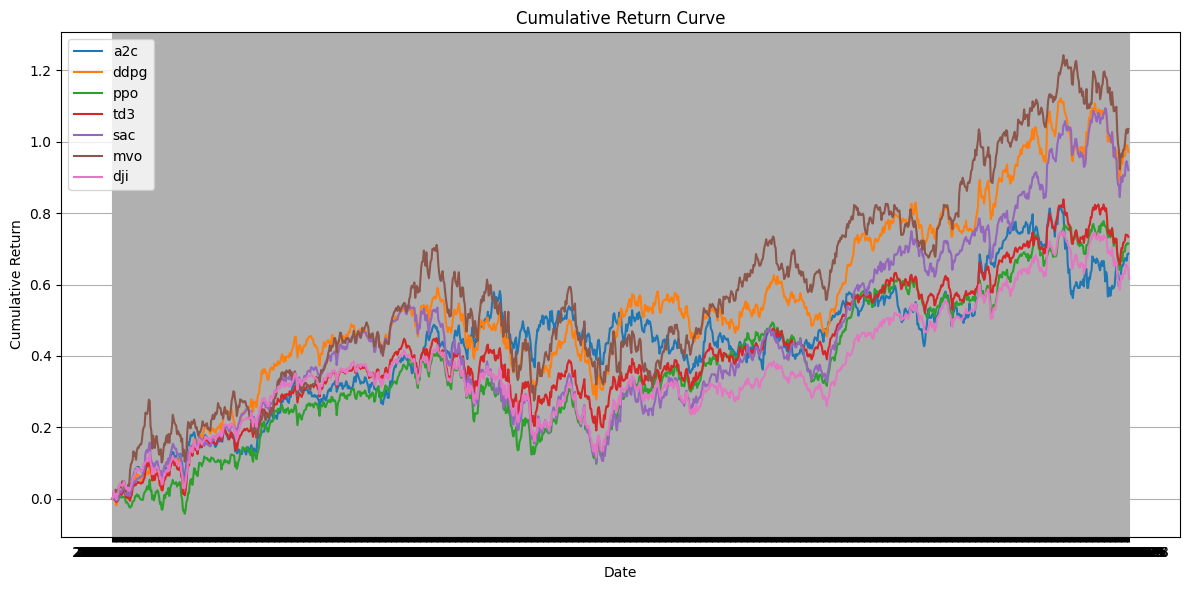

In [ ]:
def performance_metrics(series: pd.Series, trading_days_per_year=252):
    """
    Given a pd.Series of daily portfolio values (indexed by date),
    compute initial/final values, annualized return, annualized vol,
    Sharpe ratio, and max drawdown.
    """
    # drop any NaNs
    series = series.dropna()
    # initial & final
    v0 = series.iloc[0]
    vt = series.iloc[-1]
    # daily returns
    daily_ret = series.pct_change().dropna()
    # number of trading days
    n = len(daily_ret)
    # cumulative return
    cum_ret = vt / v0 - 1
    # annualized return
    ann_return = (vt / v0) ** (trading_days_per_year / n) - 1
    # annualized vol
    ann_vol = daily_ret.std() * np.sqrt(trading_days_per_year)
    # sharpe (rf=0)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
    # max drawdown
    running_max = series.cummax()
    drawdown = (series - running_max) / running_max
    max_dd = drawdown.min()
    return {
        "Initial": v0,
        "Final": vt,
        "Annualized Return": ann_return,
        "Annualized Std": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    }


metrics = {col: performance_metrics(result[col]) for col in result.columns}
metrics_df = pd.DataFrame(metrics).T

metrics_df["Initial"] = metrics_df["Initial"].map("${:,.0f}".format)
metrics_df["Final"]   = metrics_df["Final"].map("${:,.0f}".format)
metrics_df["Annualized Return"] = metrics_df["Annualized Return"].map("{:.2%}".format)
metrics_df["Annualized Std"]    = metrics_df["Annualized Std"].map("{:.2%}".format)
metrics_df["Sharpe Ratio"]      = metrics_df["Sharpe Ratio"].map("{:.2f}".format)
metrics_df["Max Drawdown"]      = metrics_df["Max Drawdown"].map("{:.2%}".format)

print("\nPerformance Summary:")
print(metrics_df)

cumret = result.divide(result.iloc[0]).subtract(1.0)  # (V_t/V_0)-1

plt.figure(figsize=(12, 6))
for col in cumret.columns:
    plt.plot(cumret.index, cumret[col], label=col)
plt.legend()
plt.title("Cumulative Return Curve")
plt.ylabel("Cumulative Return")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()
